# Simulación de Monte Carlo: cota de condicionamiento en normas 2 y 1

Queremos estudiar numéricamente cuán ajustada es la cota de error de condicionamiento para el problema

$$y = A x, \qquad \tilde y = y + \delta y, \qquad \tilde x = A^{-1} \tilde y.$$

Para cada norma $p \in \{1,2\}$:

$$\frac{\|\tilde x - x\|_p}{\|x\|_p} \leq \kappa_p(A) \frac{\|\delta y\|_p}{\|y\|_p},$$

donde $\kappa_p(A)=\|A\|_p\|A^{-1}\|_p$.

Haremos un experimento Monte Carlo usando la matriz de la DFT de dimensión creciente:

Para esta matriz sabemos que:

$$\kappa_2(A)=1, \qquad \kappa_1(A)=n.$$

Luego construimos:
- Vectores aleatorios $x$ y perturbaciones aleatorias $\delta y$.
- Comparación entre error relativo efectivo y cota teórica.
- Cálculo del factor de desvío medio entre cota y error real.

Factor de desvio medio cota/error para DFT fija:
  n=  100 -> norma 2: 1.000e+00, norma 1: 1.002e+02
  n=  166 -> norma 2: 1.000e+00, norma 1: 1.664e+02
  n=  278 -> norma 2: 1.000e+00, norma 1: 2.781e+02
  n=  464 -> norma 2: 1.000e+00, norma 1: 4.646e+02
  n=  500 -> norma 2: 1.000e+00, norma 1: 5.000e+02
  n=  774 -> norma 2: 1.000e+00, norma 1: 7.742e+02
  n= 1000 -> norma 2: 1.000e+00, norma 1: 1.000e+03
  n= 1291 -> norma 2: 1.000e+00, norma 1: 1.291e+03
  n= 2154 -> norma 2: 1.000e+00, norma 1: 2.155e+03
  n= 3593 -> norma 2: 1.000e+00, norma 1: 3.593e+03
  n= 5994 -> norma 2: 1.000e+00, norma 1: 5.994e+03
  n=10000 -> norma 2: 1.000e+00, norma 1: 1.000e+04


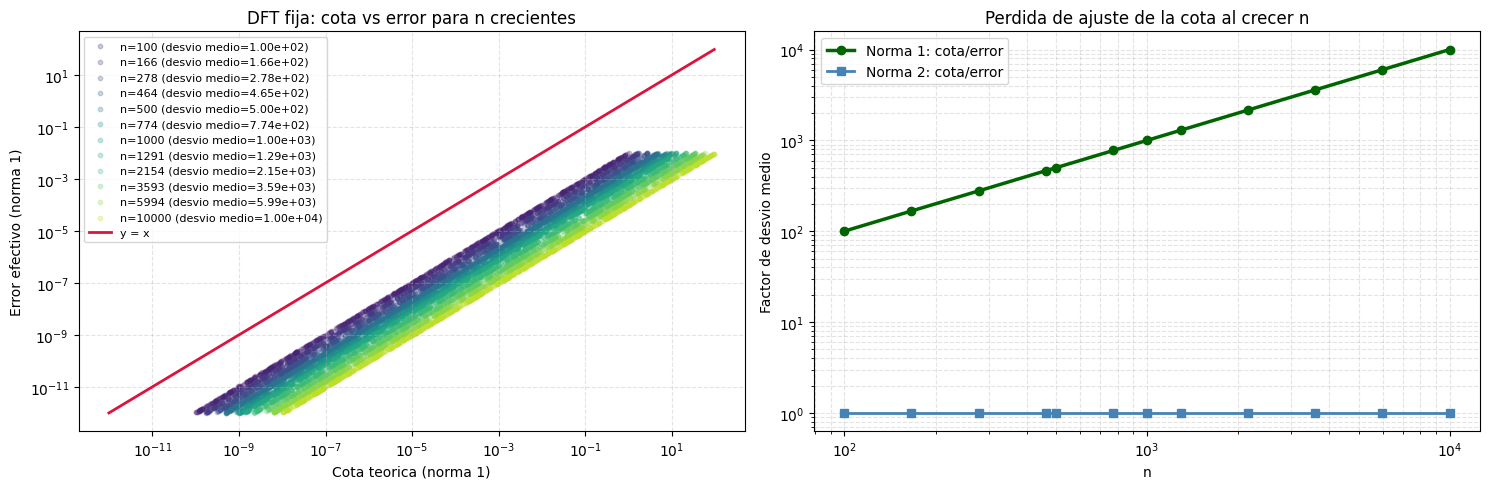

In [ ]:
# DFT fija para n crecientes
base_n = [100, 500, 1000]
n_min = 100
n_max = 10000
n_points = 10  # Cambia este valor para sumar/quitar puntos en forma general

extra_n = np.unique(np.geomspace(n_min, n_max, num=n_points).astype(int)).tolist()
n_values = sorted(set(base_n + extra_n))

N_mc = 800

desvio_medio_2 = []
desvio_medio_1 = []
all_bound_1 = []
all_err_1 = []

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
ax_scatter = axes[0]
ax_summary = axes[1]

# Colores dinamicos: uno por cada n
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(n_values)))

for color, n_i in zip(colors, n_values):
    # Para DFT normalizada: kappa_2 = 1, kappa_1 = n
    kappa2_i = 1.0
    kappa1_i = float(n_i)

    bound_2_i = np.empty(N_mc)
    err_2_i = np.empty(N_mc)
    bound_1_i = np.empty(N_mc)
    err_1_i = np.empty(N_mc)

    for t in range(N_mc):
        x = rng.standard_normal(n_i) + 1j * rng.standard_normal(n_i)
        y = np.fft.fft(x) / np.sqrt(n_i)

        d = rng.standard_normal(n_i) + 1j * rng.standard_normal(n_i)
        d /= np.linalg.norm(d, 2)
        amp = 10.0 ** rng.uniform(-12.0, -2.0)
        delta_y = amp * np.linalg.norm(y, 2) * d

        # Como A es unitaria (DFT normalizada): dx = A^* delta_y = sqrt(n) * ifft(delta_y)
        dx = np.sqrt(n_i) * np.fft.ifft(delta_y)

        rel_rhs_2 = np.linalg.norm(delta_y, 2) / np.linalg.norm(y, 2)
        rel_err_2 = np.linalg.norm(dx, 2) / np.linalg.norm(x, 2)
        bound_2_i[t] = kappa2_i * rel_rhs_2
        err_2_i[t] = rel_err_2

        rel_rhs_1 = np.linalg.norm(delta_y, 1) / np.linalg.norm(y, 1)
        rel_err_1 = np.linalg.norm(dx, 1) / np.linalg.norm(x, 1)
        bound_1_i[t] = kappa1_i * rel_rhs_1
        err_1_i[t] = rel_err_1

    desvio2 = np.mean(bound_2_i / err_2_i)
    desvio1 = np.mean(bound_1_i / err_1_i)
    desvio_medio_2.append(desvio2)
    desvio_medio_1.append(desvio1)
    all_bound_1.append(bound_1_i)
    all_err_1.append(err_1_i)

    # Scatter en norma 1: el desajuste crece con n
    ax_scatter.scatter(
        bound_1_i, err_1_i, s=10, alpha=0.25, color=color,
        label=f'n={n_i} (desvio medio={desvio1:.2e})'
    )

print('Factor de desvio medio cota/error para DFT fija:')
for n_i, d2, d1 in zip(n_values, desvio_medio_2, desvio_medio_1):
    print(f'  n={n_i:5d} -> norma 2: {d2:.3e}, norma 1: {d1:.3e}')

# Panel izquierdo: cota vs error efectivo (norma 1) con referencia y=x
bound_concat = np.concatenate(all_bound_1)
err_concat = np.concatenate(all_err_1)
lo = min(bound_concat.min(), err_concat.min())
hi = max(bound_concat.max(), err_concat.max())
line = np.logspace(np.log10(lo), np.log10(hi), 200)
ax_scatter.plot(line, line, color='crimson', lw=2, label='y = x')
ax_scatter.set_xscale('log')
ax_scatter.set_yscale('log')
ax_scatter.set_xlabel('Cota teorica (norma 1)')
ax_scatter.set_ylabel('Error efectivo (norma 1)')
ax_scatter.set_title('DFT fija: cota vs error para n crecientes')
ax_scatter.grid(True, which='both', ls='--', alpha=0.35)
ax_scatter.legend(fontsize=8)

# Panel derecho: resumen de desvio medio vs n
ax_summary.plot(n_values, desvio_medio_1, marker='o', lw=2.5, color='darkgreen', label='Norma 1: cota/error')
ax_summary.plot(n_values, desvio_medio_2, marker='s', lw=2.0, color='steelblue', label='Norma 2: cota/error')
ax_summary.set_xscale('log')
ax_summary.set_yscale('log')
ax_summary.set_xlabel('n')
ax_summary.set_ylabel('Factor de desvio medio')
ax_summary.set_title('Perdida de ajuste de la cota al crecer n')
ax_summary.grid(True, which='both', ls='--', alpha=0.35)
ax_summary.legend()

plt.tight_layout()
plt.show()